In [19]:
import pandas as pd

df = pd.read_csv(r"processed_outputs\all_rudder_cases_combined.csv")
df_prop_off = pd.read_csv(r"AERODYNAMIC_DATA_propoff\propOff.csv")

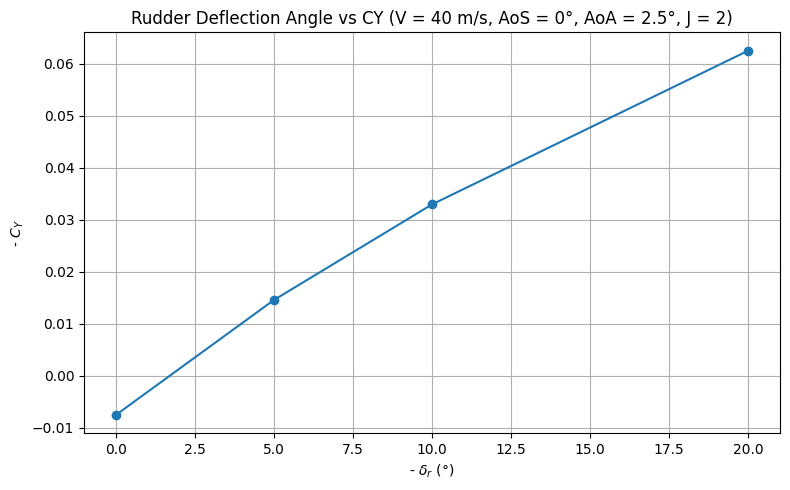

Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png


In [20]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

group_sorted = df_filtered.sort_values("rudder_deg")
ax.plot(
    -group_sorted["rudder_deg"],
    -group_sorted["CY"],
    marker="o",
    linestyle="-",
)
ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r"- $C_Y$")
ax.set_title(r"Rudder Deflection Angle vs CY (V = 40 m/s, AoS = 0°, AoA = 2.5°, J = 2)")
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png")


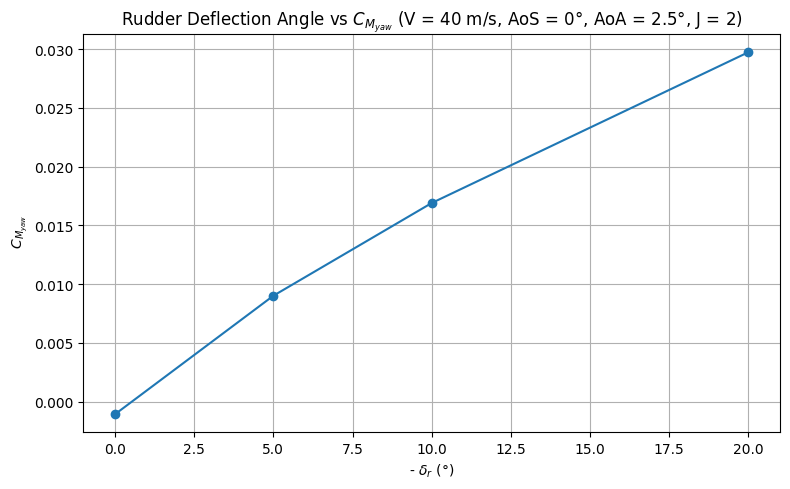

Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png


In [21]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

group_sorted = df_filtered.sort_values("rudder_deg")
ax.plot(
    -group_sorted["rudder_deg"],
    group_sorted["CMyaw"],
    marker="o",
    linestyle="-",
)
ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r" $C_{M_{yaw}}$")
ax.set_title(r"Rudder Deflection Angle vs $C_{M_{yaw}}$ (V = 40 m/s, AoS = 0°, AoA = 2.5°, J = 2)")
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png")

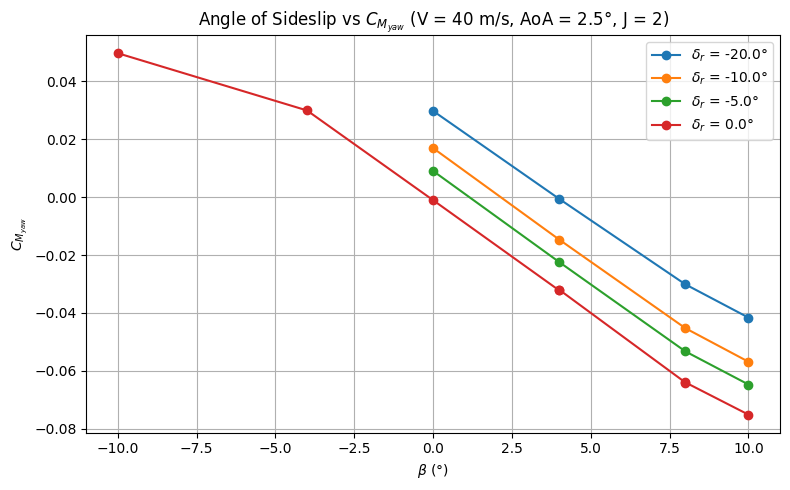

Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png


In [22]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder, group in df_filtered.groupby("rudder_deg"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CMyaw"],
        marker="o",
        linestyle="-",
        label=f"$\\delta_r$ = {rudder}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_{M_{yaw}}$")
ax.set_title(r"Angle of Sideslip vs $C_{M_{yaw}}$ (V = 40 m/s, AoA = 2.5°, J = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png")


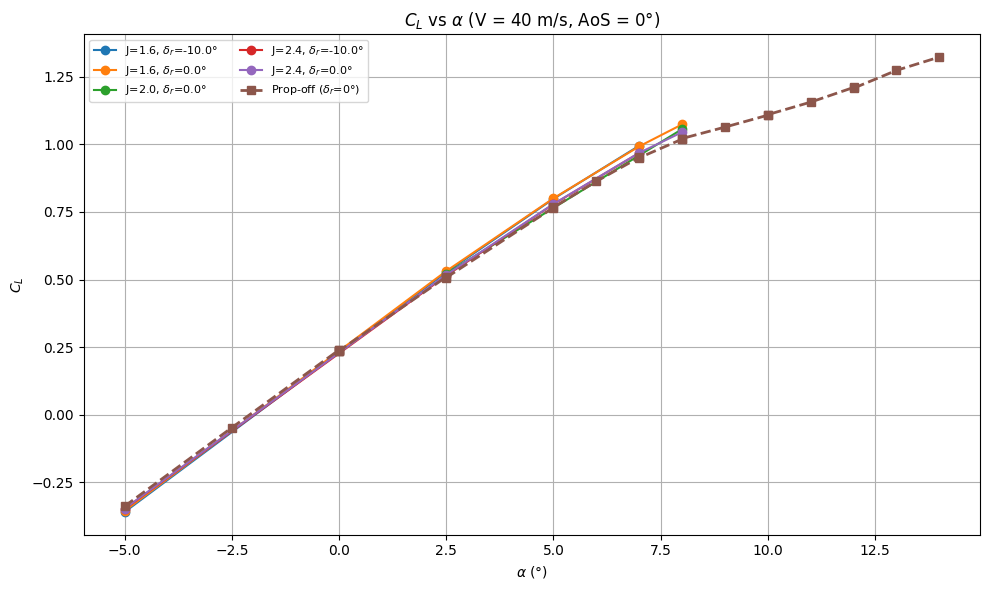

Saved to plot_images/CL_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png


In [27]:
import os
import matplotlib.pyplot as plt

# Make sure output folder exists
os.makedirs("plot_images", exist_ok=True)

# -----------------------------------
# Create rounded columns if missing
# -----------------------------------
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()

if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()

if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# -----------------------------------
# Filter prop-on data
# -----------------------------------
df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0)
].copy()

# -----------------------------------
# Filter prop-off data
# Here also choosing dR = 0 and dE = 0
# -----------------------------------
df_prop_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
].copy()

# Keep only prop-on groups with more than one unique AoA value
valid_groups = (
    df_filtered.groupby(["J_round", "rudder_deg"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

# Sort prop-off data by AoA
df_prop_off_filtered = df_prop_off_filtered.sort_values("AoA_round")

# -----------------------------------
# Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all prop-on curves
for _, row in valid_groups.iterrows():
    j_val = row["J_round"]
    rudder_val = row["rudder_deg"]

    group = df_filtered[
        (df_filtered["J_round"] == j_val) &
        (df_filtered["rudder_deg"] == rudder_val)
    ].sort_values("AoA_round")

    ax.plot(
        group["AoA_round"],
        group["CL"],
        marker="o",
        linestyle="-",
        label=f"J={j_val}, $\\delta_r$={rudder_val}°"
    )

# Plot prop-off curve
if not df_prop_off_filtered.empty:
    ax.plot(
        df_prop_off_filtered["AoA_round"],
        df_prop_off_filtered["CL"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Prop-off ($\\delta_r$=0°)"
    )
else:
    print("Warning: no matching prop-off data found.")

# Labels and styling
ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_L$")
ax.set_title(r"$C_L$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True)

# Save and show
save_path = "plot_images/CL_vs_alpha_V40_AoS0_all_J_rudders_with_propoff.png"
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"Saved to {save_path}")

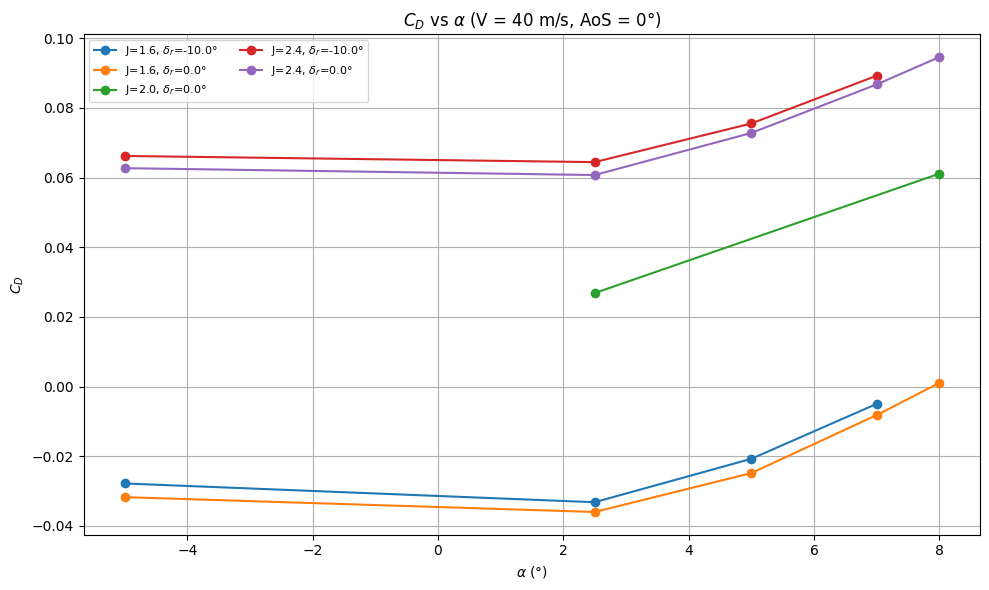

Saved to plot_images/CD_vs_alpha_V40_AoS0_all_J_rudders.png


In [24]:
import matplotlib.pyplot as plt

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0)]

valid_groups = (
    df_filtered.groupby(["J_round", "rudder_deg"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in valid_groups.iterrows():
    j_val = row["J_round"]
    rudder_val = row["rudder_deg"]
    group = df_filtered[
        (df_filtered["J_round"] == j_val) & (df_filtered["rudder_deg"] == rudder_val)
    ].sort_values("AoA_round")
    ax.plot(
        group["AoA_round"],
        group["CD"],
        marker="o",
        linestyle="-",
        label=f"J={j_val}, $\\delta_r$={rudder_val}°",
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_D$")
ax.set_title(r"$C_D$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CD_vs_alpha_V40_AoS0_all_J_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/CD_vs_alpha_V40_AoS0_all_J_rudders.png")


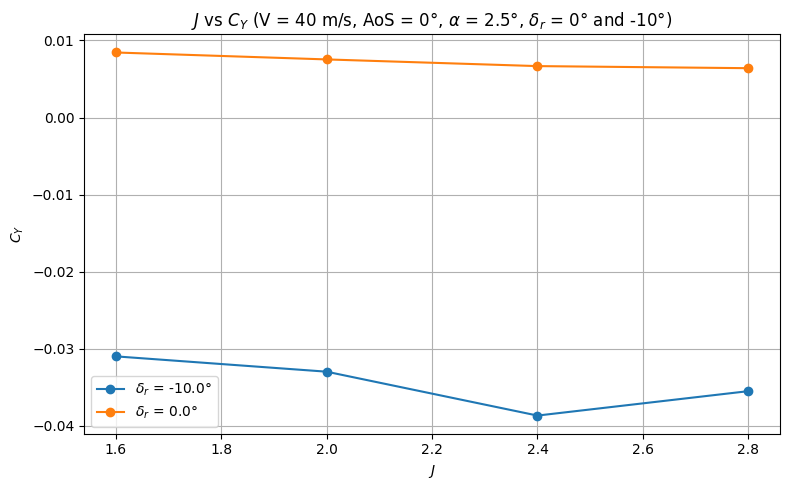

Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png


In [28]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["rudder_deg"].isin([0, -10]))
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("rudder_deg"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CY"],
        marker="o",
        linestyle="-",
        label=f"$\\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$C_Y$")
ax.set_title(r"$J$ vs $C_Y$ (V = 40 m/s, AoS = 0°, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png", dpi=150)
plt.show()
print("Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png")


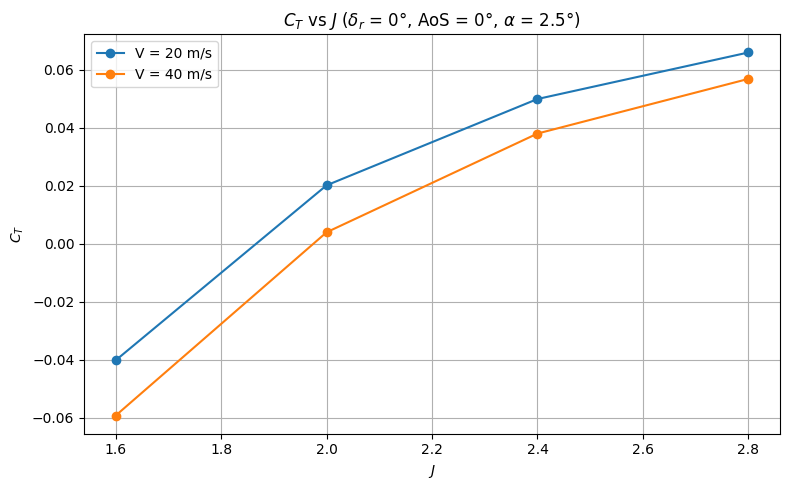

Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png


In [30]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["rudder_deg"] == 0)
]

fig, ax = plt.subplots(figsize=(8, 5))

for v_val, group in df_filtered.groupby("V_round"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CT"],
        marker="o",
        linestyle="-",
        label=f"V = {v_val} m/s",
    )

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$C_T$")
ax.set_title(r"$C_T$ vs $J$ ($\delta_r$ = 0°, AoS = 0°, $\alpha$ = 2.5°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png")


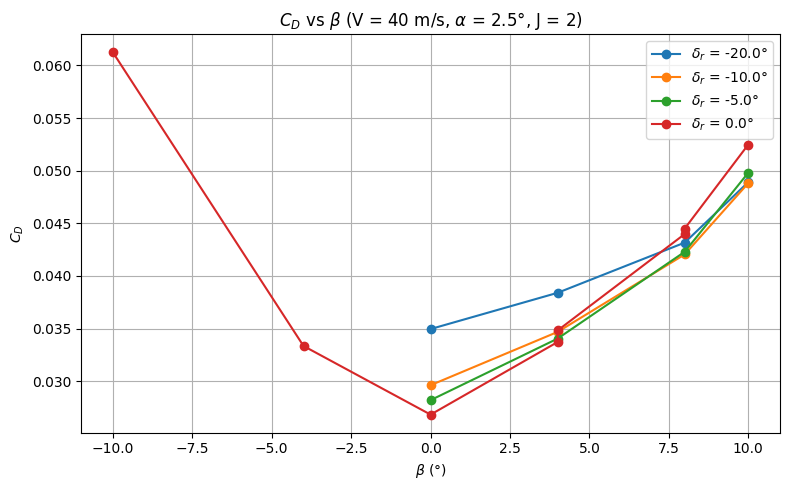

Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png


In [34]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoA_round"] == 2.5) &
    (df["J_round"] == 2)
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("rudder_deg"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CD"],
        marker="o",
        linestyle="-",
        label=f"$\\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_D$")
ax.set_title(r"$C_D$ vs $\beta$ (V = 40 m/s, $\alpha$ = 2.5°, J = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png")


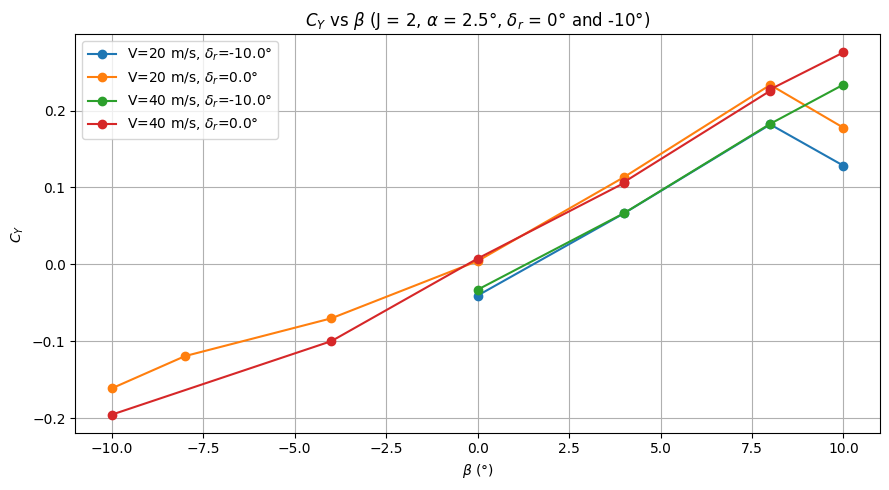

Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png


In [35]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["rudder_deg"].isin([0, -10])) &
    (df["J_round"] == 2) &
    (df["AoA_round"] == 2.5)
]

fig, ax = plt.subplots(figsize=(9, 5))

for (v_val, rudder_val), group in df_filtered.groupby(["V_round", "rudder_deg"]):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CY"],
        marker="o",
        linestyle="-",
        label=f"V={v_val} m/s, $\\delta_r$={rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_Y$")
ax.set_title(r"$C_Y$ vs $\beta$ (J = 2, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png", dpi=150)
plt.show()
print("Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png")


In [ ]:
import matplotlib.pyplot as plt

# Filter prop on J=1.6
df_on_filtered_16 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["rudder_deg"] == 0) & 
    (df["J_round"] == 1.6)
].sort_values("AoA_round")

# Filter prop on J=2.4
df_on_filtered_24 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["rudder_deg"] == 0) & 
    (df["J_round"] == 2.4)
].sort_values("AoA_round")

# Filter prop off
df_off_filtered = df_prop_off[
    (round(df_prop_off["V"]) == 40) & 
    (round(df_prop_off["AoS_round"]) == 0) & 
    (df_prop_off["rudder_deg"] == 0)
].sort_values("AoA_round")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_filtered_16["AoA_round"],
    df_on_filtered_16["CMpitch"],
    marker="o",
    linestyle="-",
    label="Prop On (J = 1.6)"
)

ax.plot(
    df_on_filtered_24["AoA_round"],
    df_on_filtered_24["CMpitch"],
    marker="^",
    linestyle="-",
    label="Prop On (J = 2.4)"
)

ax.plot(
    df_off_filtered["AoA_round"],
    df_off_filtered["CMpitch"],
    marker="s",
    linestyle="--",
    label="Prop Off"
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}}$")
ax.set_title(r"$C_{M_{pitch}}$ vs $\alpha$ (V = 40 m/s, AoS = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png")

KeyError: 'V_round'